# Loan Default Prediction — K-Nearest Neighbours (KNN)
## UTS 31250 Data Mining — Assignment 3

This notebook implements a **complete pipeline** for predicting loan default using **K-Nearest Neighbours (KNN)**.

**Structure:**
1. Setup & Libraries
2. Load Data
3. Data Cleaning & Preprocessing
4. EDA
5. Feature Engineering
6. Train/Test Split
7. K-Nearest Neighbours (KNN) — Baseline & Tuned
8. Evaluation & Metrics
9. Feature Importance
10. Predict Unknown & Kaggle Submission

---
# 1. Setup & Libraries

Run the cells below to install and import everything needed.

> **Tip:** If libraries are already installed (e.g., via Anaconda), skip the pip cell.

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
print('All libraries imported successfully!')

All libraries imported successfully!


---
# 2. Load the Data

Place both CSV files in the **same folder** as this notebook.
```
my_project/
├── this_notebook.ipynb
├── Assignment3-Loan-Dataset.csv
└── Assignment3-Unknown-Dataset.csv
```

In [3]:
# ── Load both datasets ──
df_loan = pd.read_csv('Assignment3-Loan-Dataset.csv')
df_unknown = pd.read_csv('Assignment3-Unknown-Dataset.csv')

print(f'Loan Dataset     : {df_loan.shape[0]:,} rows x {df_loan.shape[1]} columns')
print(f'Unknown Dataset  : {df_unknown.shape[0]:,} rows x {df_unknown.shape[1]} columns')

Loan Dataset     : 35,000 rows x 20 columns
Unknown Dataset  : 15,000 rows x 19 columns


In [4]:
df_loan.head()

,age,income,credit_score,loan_amount,debt_to_income_pct,num_dependents,years_employed,account_balance,num_prev_loans,monthly_expenses,gender,employment_status,education_level,loan_purpose,region,marital_status,application_year,loan_duration_months,application_date,loan_default
0,56,70760.04,802,11846.59,67.15,1.0,11.7,NaN,8,19630.68,Female,Self-Employed,NaN,Business,South,Married,2018,24,2018-06-23,1
1,69,31366.22,629,58014.20,21.87,NaN,5.7,2077.13,9,5329.77,Male,Part-Time,Master,Education,Central,Single,2018,36,2018-03-06,1
2,46,23374.68,608,19059.09,16.07,0.0,NaN,8815.60,2,4528.69,Female,Self-Employed,Master,Education,East,Single,2023,84,2023-05-04,0
3,32,46647.88,638,57194.52,18.88,0.0,0.8,2253.18,5,7815.41,Female,Full-Time,Master,Personal,South,Widowed,2015,12,2015-02-04,1
4,60,49864.95,647,19768.34,19.00,2.0,NaN,17106.10,6,14020.53,Male,Part-Time,High School,Education,Central,NaN,2024,60,2024-03-18,1


In [5]:
df_loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   35000 non-null  int64  
 1   income                32903 non-null  float64
 2   credit_score          35000 non-null  int64  
 3   loan_amount           35000 non-null  float64
 4   debt_to_income_pct    35000 non-null  float64
 5   num_dependents        33190 non-null  float64
 6   years_employed        32296 non-null  float64
 7   account_balance       32570 non-null  float64
 8   num_prev_loans        35000 non-null  int64  
 9   monthly_expenses      31741 non-null  float64
 10  gender                35000 non-null  object 
 11  employment_status     35000 non-null  object 
 12  education_level       29272 non-null  object 
 13  loan_purpose          35000 non-null  object 
 14  region                35000 non-null  object 
 15  marital_status     

In [6]:
# ── Check missing values ──
missing = df_loan.isnull().sum()
missing_pct = (missing / len(df_loan) * 100).round(2)
missing_info = pd.DataFrame({'Count': missing, 'Percent': missing_pct})
print(missing_info[missing_info['Count'] > 0].sort_values('Percent', ascending=False))

                  Count  Percent
education_level    5728    16.37
marital_status     4216    12.05
monthly_expenses   3259     9.31
years_employed     2704     7.73
account_balance    2430     6.94
income             2097     5.99
num_dependents     1810     5.17


---
# 3. Data Cleaning & Preprocessing

### Strategy:
1. Drop raw `application_date` (keep `application_year`)
2. Fill missing numerical values with **median** (robust to skew)
3. Fill missing categorical values with `'Unknown'`
4. One-hot encode all categorical features
5. Apply **all steps identically** to both datasets

> **Critical:** Every preprocessing step applied to training data must be applied identically to the unknown data.

In [7]:
# ── Drop date column ──
df_loan = df_loan.drop(columns=['application_date'], errors='ignore')
df_unknown = df_unknown.drop(columns=['application_date'], errors='ignore')

# ── Identify column types ──
target = 'loan_default'
numerical_cols = df_loan.select_dtypes(include=['int64','float64']).columns.tolist()
numerical_cols = [c for c in numerical_cols if c != target]
categorical_cols = df_loan.select_dtypes(include=['object']).columns.tolist()

print(f'Numerical:  {numerical_cols}')
print(f'Categorical: {categorical_cols}')

Numerical:  ['age', 'income', 'credit_score', 'loan_amount', 'debt_to_income_pct', 'num_dependents', 'years_employed', 'account_balance', 'num_prev_loans', 'monthly_expenses', 'application_year', 'loan_duration_months']
Categorical: ['gender', 'employment_status', 'education_level', 'loan_purpose', 'region', 'marital_status']


In [8]:
# ── Handle missing values ──
# Median for numbers (robust to outliers), 'Unknown' for categories
medians = {}
for col in numerical_cols:
    medians[col] = df_loan[col].median()
    df_loan[col] = df_loan[col].fillna(medians[col])
    df_unknown[col] = df_unknown[col].fillna(medians[col])

for col in categorical_cols:
    df_loan[col] = df_loan[col].fillna('Unknown')
    df_unknown[col] = df_unknown[col].fillna('Unknown')

print(f'Remaining NaN in loan:    {df_loan.isnull().sum().sum()}')
print(f'Remaining NaN in unknown: {df_unknown.isnull().sum().sum()}')

Remaining NaN in loan:    0
Remaining NaN in unknown: 0


In [9]:
# ── One-hot encode (both datasets together for consistency) ──
df_loan['_source'] = 'loan'
df_unknown['_source'] = 'unknown'
df_unknown[target] = np.nan

combined = pd.concat([df_loan, df_unknown], axis=0, ignore_index=True)
combined = pd.get_dummies(combined, columns=categorical_cols, drop_first=True, dtype=int)

df_loan_enc = combined[combined['_source']=='loan'].drop(columns=['_source']).reset_index(drop=True)
df_unknown_enc = combined[combined['_source']=='unknown'].drop(columns=['_source',target]).reset_index(drop=True)

print(f'Loan encoded:    {df_loan_enc.shape}')
print(f'Unknown encoded: {df_unknown_enc.shape}')
print(f'Columns match: {set(df_loan_enc.columns)-{target} == set(df_unknown_enc.columns)}')

Loan encoded:    (35000, 36)
Unknown encoded: (15000, 35)
Columns match: True


---
# 4. Exploratory Data Analysis

Quick visual check of class imbalance and feature relationships.

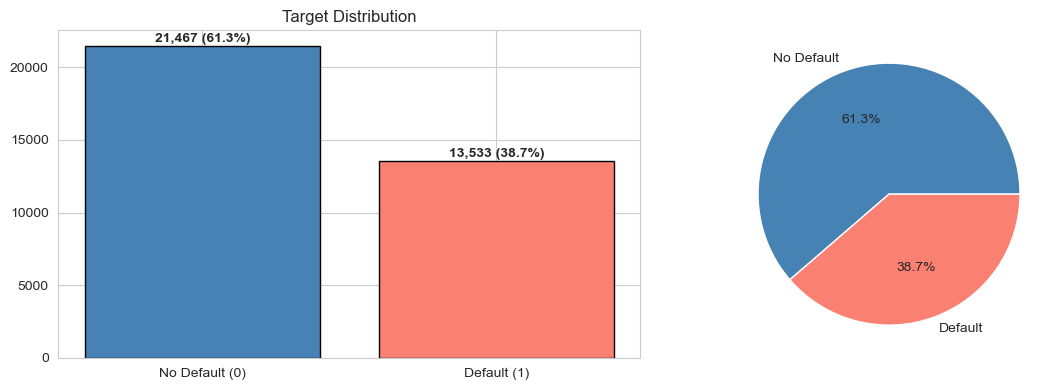

Majority baseline: 61.3%


In [10]:
# ── Class distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df_loan_enc[target].value_counts()
axes[0].bar(['No Default (0)','Default (1)'], counts.values, color=['steelblue','salmon'], edgecolor='black')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+300, f'{v:,} ({v/len(df_loan_enc)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Target Distribution')
axes[1].pie(counts.values, labels=['No Default','Default'], autopct='%1.1f%%', colors=['steelblue','salmon'])
plt.tight_layout()
plt.show()
print(f'Majority baseline: {counts.max()/len(df_loan_enc):.1%}')

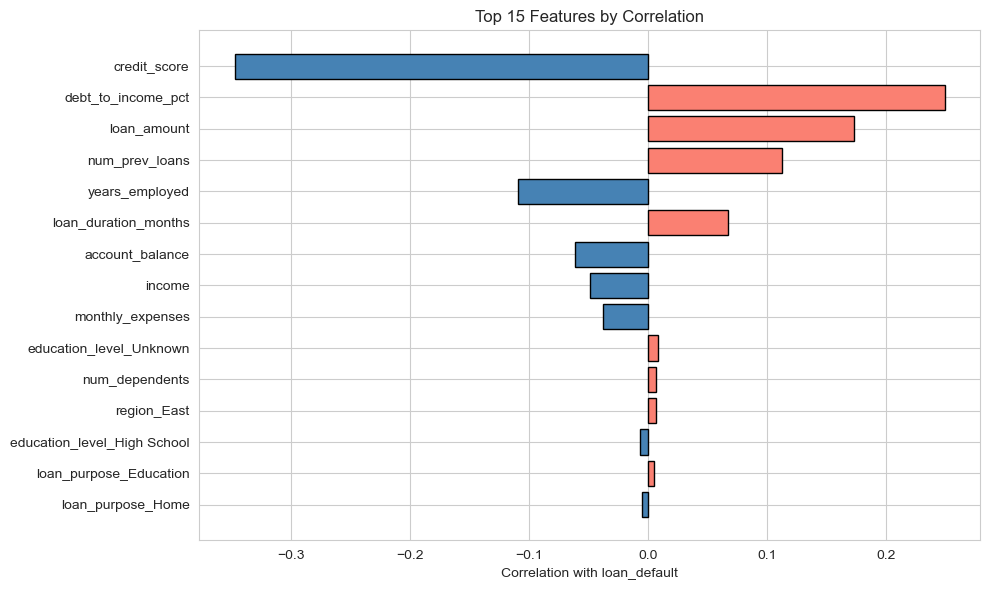

In [11]:
# ── Top correlations with target ──
corr = df_loan_enc.select_dtypes('number').corr()[target].drop(target).sort_values(key=abs, ascending=False)
top = corr.head(15)
plt.figure(figsize=(10,6))
plt.barh(top.index, top.values, color=['salmon' if v>0 else 'steelblue' for v in top.values], edgecolor='black')
plt.xlabel('Correlation with loan_default')
plt.title('Top 15 Features by Correlation')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
# 5. Feature Engineering

Creating domain-informed ratio features that capture risk better than raw values.

In [12]:
for df in [df_loan_enc, df_unknown_enc]:
    df['loan_to_income'] = df['loan_amount'] / df['income'].replace(0, np.nan)
    df['loan_to_income'] = df['loan_to_income'].fillna(df['loan_to_income'].median())
    
    df['expense_to_income'] = df['monthly_expenses'] / df['income'].replace(0, np.nan)
    df['expense_to_income'] = df['expense_to_income'].fillna(df['expense_to_income'].median())
    
    df['balance_to_loan'] = df['account_balance'] / df['loan_amount'].replace(0, np.nan)
    df['balance_to_loan'] = df['balance_to_loan'].fillna(df['balance_to_loan'].median())

print(f'Features after engineering: {df_loan_enc.shape[1]}')

Features after engineering: 39


---
# 6. Train/Test Split

80% training, 20% testing. Stratified to preserve class ratio.

In [13]:
feature_cols = [c for c in df_loan_enc.columns if c != target]
X = df_loan_enc[feature_cols]
y = df_loan_enc[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Feature Scaling (REQUIRED for K-Nearest Neighbours (KNN)) ──
# K-Nearest Neighbours (KNN) computes distances — features with larger ranges
# would dominate without scaling. StandardScaler makes all features mean=0, std=1.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train ONLY
X_test_scaled = scaler.transform(X_test)          # transform test with train stats

print(f'Scaling applied (fit on train, transform both) ✓')
print(f'Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows | Features: {X_train.shape[1]}')
print(f'Train default rate: {y_train.mean():.3f} | Test default rate: {y_test.mean():.3f}')

Scaling applied (fit on train, transform both) ✓
Train: 28,000 rows | Test: 7,000 rows | Features: 38
Train default rate: 0.387 | Test default rate: 0.387


---
# 7. K-Nearest Neighbours (KNN)

### How KNN Works
KNN classifies a new data point by looking at its **k closest neighbours** in the training data and taking a majority vote. If 30 of 51 neighbours are 'Default', the prediction is 'Default'.

### Key Parameters
| Parameter | What it does | Effect |
|---|---|---|
| `n_neighbors` (k) | Number of neighbours to consult | Small k = noisy; large k = smooth |
| `metric` | Distance formula | Manhattan is better in high dimensions |
| `weights` | How neighbours vote | `distance` = closer neighbours count more |

### Advantages & Disadvantages
| ✅ Advantages | ❌ Disadvantages |
|---|---|
| Simple to understand | Slow at prediction time (scans all training data) |
| No training phase | Requires feature scaling |
| Works well with enough data | Sensitive to irrelevant features |

### ⚠️ Scaling is CRITICAL for KNN
Without scaling, a feature like `income` (range 0–500,000) completely dominates `num_dependents` (range 0–5) in distance calculations.

In [14]:
# ── Baseline: KNN with default k=5 ──
knn_baseline = KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1)
knn_baseline.fit(X_train_scaled, y_train)

train_acc = accuracy_score(y_train, knn_baseline.predict(X_train_scaled))
test_acc = accuracy_score(y_test, knn_baseline.predict(X_test_scaled))
print(f'Baseline KNN (k=5, Euclidean)')
print(f'  Train accuracy: {train_acc:.4f}')
print(f'  Test accuracy:  {test_acc:.4f}')

Baseline KNN (k=5, Euclidean)
  Train accuracy: 0.7738
  Test accuracy:  0.6520


---
# 8. Model Evaluation

### Why accuracy alone is NOT enough
With 61% non-defaults, always predicting 'No Default' gives 61% accuracy but catches zero defaults.

| Metric | Measures | Why it matters |
|---|---|---|
| **Accuracy** | Overall correct % | Misleading with imbalanced data |
| **Precision** | Of predicted defaults, how many are real? | Reduces false alarms |
| **Recall** | Of actual defaults, how many did we catch? | Catches risky borrowers |
| **F1-Score** | Balance of precision & recall | Best single metric |
| **ROC-AUC** | Discrimination across all thresholds | Best overall measure |

In [15]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name='Model'):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    
    train_acc = accuracy_score(y_tr, model.predict(X_tr))
    test_acc = accuracy_score(y_te, y_pred)
    
    print(f'\n{"="*55}')
    print(f'  {model_name} — Results')
    print(f'{"="*55}')
    print(f'  Train Accuracy : {train_acc:.4f}')
    print(f'  Test Accuracy  : {test_acc:.4f}')
    print(f'  Overfit Gap    : {train_acc - test_acc:.4f}')
    print(f'  Precision      : {precision_score(y_te, y_pred):.4f}')
    print(f'  Recall         : {recall_score(y_te, y_pred):.4f}')
    print(f'  F1-Score       : {f1_score(y_te, y_pred):.4f}')
    print(f'  F1-macro       : {f1_score(y_te, y_pred, average="macro"):.4f}')
    print(f'  ROC-AUC        : {roc_auc_score(y_te, y_prob):.4f}')
    print(f'\n{classification_report(y_te, y_pred, target_names=["No Default","Default"], digits=4)}')
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, display_labels=['No Default','Default'], cmap='Blues', ax=axes[0])
    axes[0].set_title(f'{model_name} — Confusion Matrix')
    RocCurveDisplay.from_predictions(y_te, y_prob, ax=axes[1], name=model_name)
    axes[1].plot([0,1],[0,1],'k--'); axes[1].set_title(f'{model_name} — ROC Curve')
    plt.tight_layout(); plt.show()
    
    return {'accuracy': test_acc, 'f1': f1_score(y_te, y_pred), 'auc': roc_auc_score(y_te, y_prob)}



  Baseline K-Nearest Neighbours (KNN) — Results
  Train Accuracy : 0.7738
  Test Accuracy  : 0.6520
  Overfit Gap    : 0.1218
  Precision      : 0.5760
  Recall         : 0.3794
  F1-Score       : 0.4575
  F1-macro       : 0.6007
  ROC-AUC        : 0.6507

              precision    recall  f1-score   support

  No Default     0.6780    0.8239    0.7438      4293
     Default     0.5760    0.3794    0.4575      2707

    accuracy                         0.6520      7000
   macro avg     0.6270    0.6016    0.6007      7000
weighted avg     0.6385    0.6520    0.6331      7000



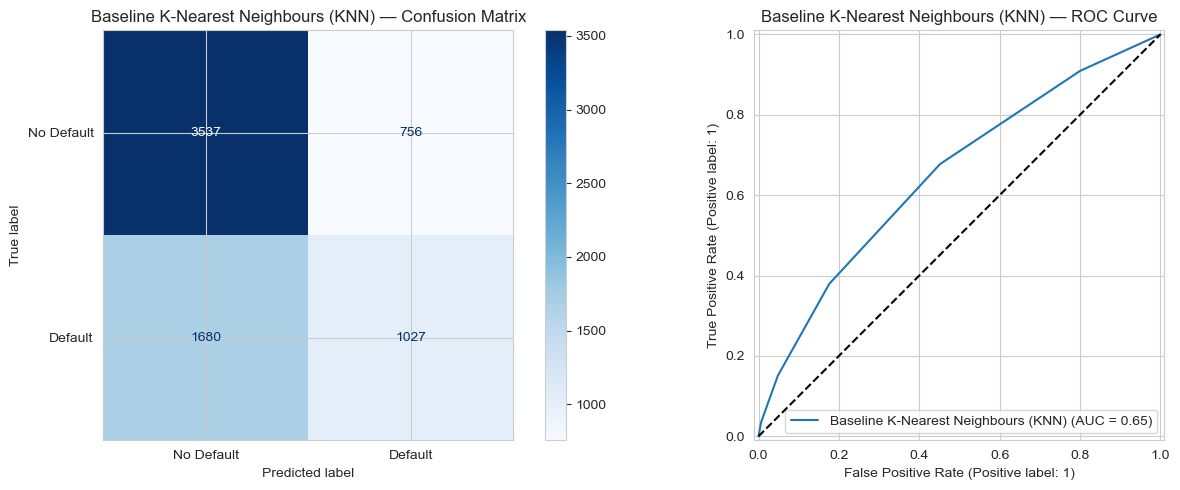

In [16]:
# ── Evaluate the baseline ──
baseline_var = knn_baseline
baseline_results = evaluate_model(knn_baseline,
    X_train_scaled, y_train, X_test_scaled, y_test, 'Baseline K-Nearest Neighbours (KNN)')

---
# 9. Hyperparameter Tuning (GridSearchCV)

GridSearchCV tries every combination of parameters using cross-validation and picks the best.

> **Note:** This may take a few minutes.

In [17]:
param_grid = {
    'n_neighbors': [5, 11, 21, 31, 51],
    'metric': ['euclidean', 'manhattan'],
    'weights': ['uniform', 'distance'],
}

grid_search = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1_macro', n_jobs=-1, verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print(f'\n=== Best Parameters ===')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'Best CV F1-macro: {grid_search.best_score_:.4f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits

=== Best Parameters ===
  metric: manhattan
  n_neighbors: 11
  weights: uniform
Best CV F1-macro: 0.6106



  Tuned K-Nearest Neighbours (KNN) — Results
  Train Accuracy : 0.7467
  Test Accuracy  : 0.6844
  Overfit Gap    : 0.0623
  Precision      : 0.6763
  Recall         : 0.3528
  F1-Score       : 0.4637
  F1-macro       : 0.6201
  ROC-AUC        : 0.7060

              precision    recall  f1-score   support

  No Default     0.6865    0.8935    0.7764      4293
     Default     0.6763    0.3528    0.4637      2707

    accuracy                         0.6844      7000
   macro avg     0.6814    0.6232    0.6201      7000
weighted avg     0.6826    0.6844    0.6555      7000



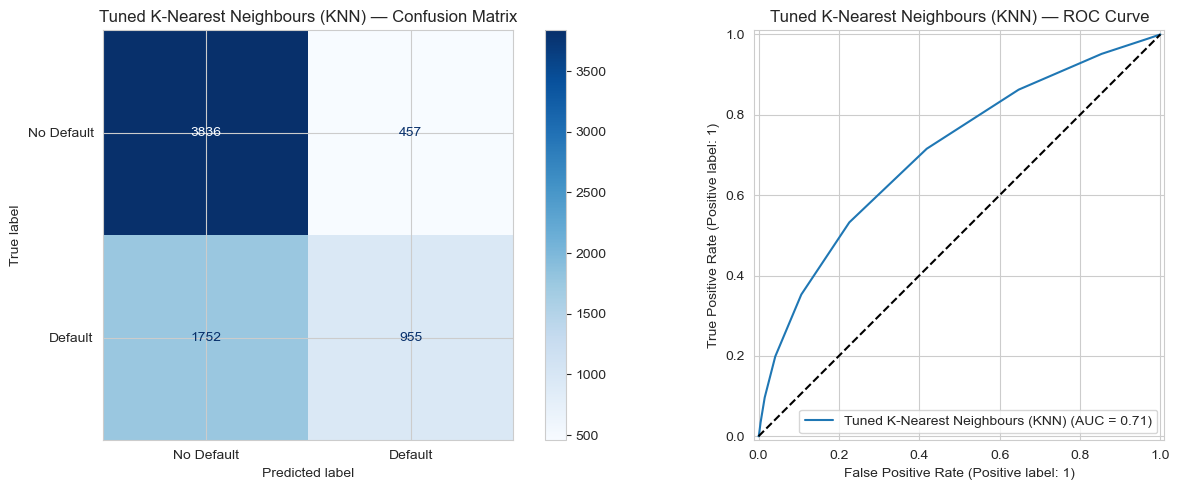

In [18]:
# ── Evaluate the tuned model ──
knn_tuned = grid_search.best_estimator_
tuned_results = evaluate_model(knn_tuned, X_train_scaled, y_train, X_test_scaled, y_test, 'Tuned K-Nearest Neighbours (KNN)')

In [19]:
# ── Compare Baseline vs Tuned ──
print(f'\n{"="*50}')
print(f'  BASELINE vs TUNED')
print(f'{"="*50}')
for m in ['accuracy','f1','auc']:
    b = baseline_results[m]; t = tuned_results[m]
    arrow = '↑' if t>b else '↓'
    print(f'  {m:>10s}: {b:.4f} → {t:.4f} ({arrow} {abs(t-b):.4f})')


  BASELINE vs TUNED
    accuracy: 0.6520 → 0.6844 (↑ 0.0324)
          f1: 0.4575 → 0.4637 (↑ 0.0062)
         auc: 0.6507 → 0.7060 (↑ 0.0553)


---
# 10. K-Value Analysis

KNN does not provide feature importance, but we can visualise how performance changes with k.

  k=  3  F1-macro=0.6051
  k=  5  F1-macro=0.6184
  k=  7  F1-macro=0.6176
  k=  9  F1-macro=0.6182
  k= 11  F1-macro=0.6200
  k= 15  F1-macro=0.6142
  k= 21  F1-macro=0.6095
  k= 31  F1-macro=0.6039
  k= 51  F1-macro=0.5855


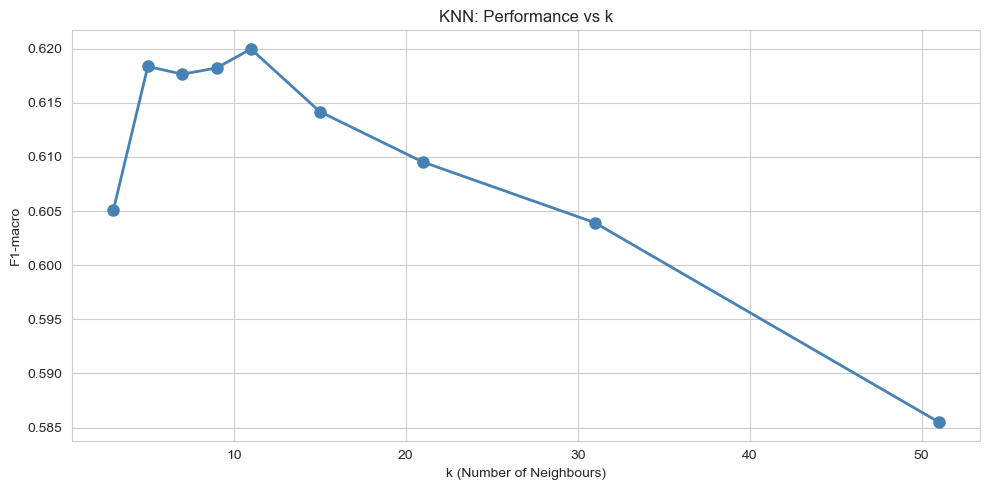

In [20]:
# ── Test different k values ──
k_values = [3,5,7,9,11,15,21,31,51]
k_scores = []
for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k, metric='manhattan', weights='distance', n_jobs=-1)
    knn_k.fit(X_train_scaled, y_train)
    score = f1_score(y_test, knn_k.predict(X_test_scaled), average='macro')
    k_scores.append(score)
    print(f'  k={k:3d}  F1-macro={score:.4f}')

plt.figure(figsize=(10,5))
plt.plot(k_values, k_scores, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.xlabel('k (Number of Neighbours)'); plt.ylabel('F1-macro')
plt.title('KNN: Performance vs k'); plt.grid(True)
plt.tight_layout(); plt.show()

---
# 11. Predict Unknown & Create Kaggle Submission

For the final submission, we retrain on **all 35,000 labelled rows** to maximise learning.

In [21]:
# ── Retrain on ALL data with best params ──
final_model = KNeighborsClassifier(**grid_search.best_params_, n_jobs=-1)
# Scale full data
scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X)
final_model.fit(X_full_scaled, y)

# Scale unknown data with SAME scaler
X_unk = df_unknown_enc[feature_cols]
X_unk_scaled = scaler_full.transform(X_unk)
predictions = final_model.predict(X_unk_scaled)

print(f'Predictions: {len(predictions):,}')
print(f'  No Default: {(predictions==0).sum():,} | Default: {(predictions==1).sum():,}')
print(f'  Default rate: {predictions.mean():.3f}')

Predictions: 15,000
  No Default: 11,828 | Default: 3,172
  Default rate: 0.211


In [22]:
# ── Create Kaggle CSV ──
submission = pd.DataFrame({{
    'row ID': [f'Row{{i}}' for i in range(len(predictions))],
    'predicted-Loan-Default': predictions.astype(int)
}})
submission.to_csv('kaggle_KNN.csv', index=False)

# Validation
print('=== Validation ===')
print(f'  Rows: {len(submission):,} {"✓" if len(submission)==15000 else "✗"}')
print(f'  Columns: {{list(submission.columns)}}')
print(f'  No NaN: {{submission.isnull().sum().sum()==0}} ✓')
print(f'  Binary: {{set(submission["predicted-Loan-Default"].unique()) <= {{0,1}}}} ✓')
print(f'\nFirst 5 rows:')
print(submission.head().to_string(index=False))
print(f'\nSaved: kaggle_KNN.csv → Upload to Kaggle!')

TypeError: unhashable type: 'dict'

---
## Summary — K-Nearest Neighbours (KNN)

| Step | What we did |
|---|---|
| Preprocessing | Median imputation, Unknown category, one-hot encoding |
| EDA | Class distribution, correlations |
| Feature Engineering | loan_to_income, expense_to_income, balance_to_loan |
| Baseline | K-Nearest Neighbours (KNN) with default settings |
| Tuning | GridSearchCV over key hyperparameters |
| Evaluation | Accuracy, F1, AUC, confusion matrix |
| Kaggle | Retrain on full data, predict unknown, save CSV |